In [2]:
!pip -q install yfinance scipy numpy pandas

import numpy as np
import pandas as pd
import yfinance as yf

from scipy.optimize import minimize
from scipy.stats import norm

In [3]:
def bs_price(F, K, T, sigma, df=1.0, is_call=True):
    """Black-76 (по форварду), discount factor df. Удобно для SABR.
    Если хочешь классический BS по spot — скажи, переделаем."""
    if T <= 0 or sigma <= 0 or F <= 0 or K <= 0:
        return np.nan

    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / vol_sqrt
    d2 = d1 - vol_sqrt

    if is_call:
        return df * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        return df * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


def implied_vol_black76(price, F, K, T, df=1.0, is_call=True, 
                        sigma_low=1e-6, sigma_high=5.0, max_iter=100):
    """Быстрый брутфорс/бисекция для implied vol Black-76."""
    if np.isnan(price) or price <= 0 or T <= 0 or F <= 0 or K <= 0:
        return np.nan

    # теоретические границы (очень грубо)
    intrinsic = df * max(F - K, 0) if is_call else df * max(K - F, 0)
    if price < intrinsic:
        return np.nan

    lo, hi = sigma_low, sigma_high
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        pmid = bs_price(F, K, T, mid, df=df, is_call=is_call)
        if np.isnan(pmid):
            return np.nan
        if pmid > price:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def sabr_hagan_lognormal(F, K, T, alpha, beta, rho, nu):
    """Hagan lognormal SABR implied vol (Black vol)."""
    if F <= 0 or K <= 0 or T <= 0:
        return np.nan
    if alpha <= 0 or nu <= 0 or beta < 0 or beta > 1 or abs(rho) >= 1:
        return np.nan

    one_minus_beta = 1.0 - beta

    # Handle ATM separately
    if np.isclose(F, K):
        FK_beta = F**one_minus_beta
        term1 = alpha / FK_beta
        term2 = (
            (one_minus_beta**2 / 24) * (alpha**2 / (F**(2*one_minus_beta))) +
            (rho * beta * nu * alpha / (4 * F**one_minus_beta)) +
            ((2 - 3*rho**2) * nu**2 / 24)
        ) * T
        return term1 * (1 + term2)

    logFK = np.log(F / K)
    FK = F * K
    FK_beta = FK**(0.5 * one_minus_beta)

    z = (nu / alpha) * FK_beta * logFK
    xz = np.log((np.sqrt(1 - 2*rho*z + z*z) + z - rho) / (1 - rho))

    # series expansion terms
    A = alpha / (FK_beta * (1 + (one_minus_beta**2 / 24) * logFK**2 + (one_minus_beta**4 / 1920) * logFK**4))
    B = z / xz
    C = 1 + (
        (one_minus_beta**2 / 24) * (alpha**2 / (FK**(one_minus_beta))) +
        (rho * beta * nu * alpha / (4 * FK_beta)) +
        ((2 - 3*rho**2) * nu**2 / 24)
    ) * T

    return A * B * C

In [4]:
ticker = "AAPL"  # поменяй на что хочешь
t = yf.Ticker(ticker)

spot = float(t.history(period="1d")["Close"].iloc[-1])
expiries = t.options

spot, expiries[:5], len(expiries)

(264.17999267578125,
 ('2026-03-02', '2026-03-04', '2026-03-06', '2026-03-13', '2026-03-20'),
 22)

In [5]:
expiry = expiries[0]  # можно выбрать другую дату из списка
chain = t.option_chain(expiry)

calls = chain.calls.copy()
puts  = chain.puts.copy()

calls.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL260302C00190000,2026-02-17 20:54:50+00:00,190.0,73.25,72.30,76.0,0.00,0.000000,NaN,29,3.137697,True,REGULAR,USD
1,AAPL260302C00220000,2026-02-25 16:02:42+00:00,220.0,54.00,42.35,45.5,0.00,0.000000,4.0,5,1.826173,True,REGULAR,USD
2,AAPL260302C00240000,2026-02-27 20:47:50+00:00,240.0,25.10,23.15,25.2,-7.35,-22.650232,3.0,9,1.049809,True,REGULAR,USD
3,AAPL260302C00242500,2026-02-20 17:22:01+00:00,242.5,20.00,19.85,22.8,0.00,0.000000,1.0,1,0.992676,True,REGULAR,USD
4,AAPL260302C00245000,2026-02-24 19:20:52+00:00,245.0,27.18,17.40,20.3,0.00,0.000000,2.0,3,0.906739,True,REGULAR,USD


In [6]:
from datetime import datetime, timezone

def yearfrac(expiry_str):
    # expiry_str like "2026-03-20"
    exp = datetime.strptime(expiry_str, "%Y-%m-%d").replace(tzinfo=timezone.utc)
    now = datetime.now(timezone.utc)
    T = (exp - now).total_seconds() / (365.0 * 24 * 3600)
    return max(T, 0.0)

T = yearfrac(expiry)

# "учебные" допущения
r = 0.0
q = 0.0
F = spot * np.exp((r - q) * T)
df = np.exp(-r * T)

def compute_market_iv(df_opt, is_call=True):
    d = df_opt.copy()
    d["mid"] = 0.5 * (d["bid"].fillna(0) + d["ask"].fillna(0))
    d.loc[d["mid"] <= 0, "mid"] = np.nan
    d["iv_mid"] = [
        implied_vol_black76(p, F=F, K=K, T=T, df=df, is_call=is_call)
        for p, K in zip(d["mid"].values, d["strike"].values)
    ]
    return d

calls_iv = compute_market_iv(calls, is_call=True)
puts_iv  = compute_market_iv(puts,  is_call=False)

# возьмем улыбку по коллам (можно и по OTM объединять коллы/путы — усложнение)
smile = calls_iv[["strike", "iv_mid", "openInterest", "volume"]].dropna().copy()

# немного фильтров качества
smile = smile[(smile["iv_mid"] > 0.01) & (smile["iv_mid"] < 3.0)]
smile = smile.sort_values("strike")

smile.head(), smile.shape, (spot, F, T)

(    strike    iv_mid  openInterest  volume
 6    252.5  1.060165            20     8.0
 7    255.0  0.921977            61     6.0
 8    257.5  0.858055            22    56.0
 9    260.0  0.782466           282   209.0
 10   262.5  0.754420           162   511.0,
 (19, 4),
 (264.17999267578125, np.float64(264.17999267578125), 0.0007954252403285135))

In [7]:
beta = 1.0  # попробуй 0.5, 0.7, 1.0

K_mkt = smile["strike"].values
iv_mkt = smile["iv_mid"].values

# веса: можно без весов, либо чуть больше веса near-the-money
weights = 1.0 / (0.10 + np.abs(np.log(K_mkt / F)))  # простой хак

def objective(x):
    alpha, rho, nu = x
    # ограничения мягко
    if alpha <= 0 or nu <= 0 or abs(rho) >= 0.999:
        return 1e6

    iv_model = np.array([sabr_hagan_lognormal(F, K, T, alpha, beta, rho, nu) for K in K_mkt])
    if np.any(~np.isfinite(iv_model)):
        return 1e6

    err = (iv_model - iv_mkt)
    return np.sum(weights * err * err)

# стартовые догадки
x0 = np.array([0.2, -0.2, 0.5])  # alpha, rho, nu

bounds = [
    (1e-4, 5.0),    # alpha
    (-0.999, 0.999),# rho
    (1e-4, 5.0),    # nu
]

res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
res.success, res.fun, res.x

(True,
 np.float64(18.343336960898913),
 array([0.88708311, 0.99899998, 4.99998555]))

In [8]:
alpha_hat, rho_hat, nu_hat = res.x

smile_out = smile.copy()
smile_out["iv_sabr"] = [
    sabr_hagan_lognormal(F, K, T, alpha_hat, beta, rho_hat, nu_hat)
    for K in smile_out["strike"].values
]
smile_out["iv_diff"] = smile_out["iv_sabr"] - smile_out["iv_mid"]

smile_out.head()

,strike,iv_mid,openInterest,volume,iv_sabr,iv_diff
6,252.5,1.060165,20,8.0,0.768697,-0.291469
7,255.0,0.921977,61,6.0,0.795549,-0.126429
8,257.5,0.858055,22,56.0,0.821515,-0.036540
9,260.0,0.782466,282,209.0,0.846677,0.064211
10,262.5,0.754420,162,511.0,0.871104,0.116683


In [9]:
K_target = float(np.round(spot))  # например ATM
is_call = True

iv_sabr = sabr_hagan_lognormal(F, K_target, T, alpha_hat, beta, rho_hat, nu_hat)
price_sabr = bs_price(F, K_target, T, iv_sabr, df=df, is_call=is_call)

iv_sabr, price_sabr

row = calls_iv.loc[np.isclose(calls_iv["strike"], K_target)].head(1)
row[["strike","bid","ask","mid","iv_mid"]], price_sabr

(Empty DataFrame
 Columns: [strike, bid, ask, mid, iv_mid]
 Index: [],
 np.float64(2.72188027859454))

In [12]:
def make_otm_smile(calls_iv, puts_iv, F, spot):
    c = calls_iv.copy()
    p = puts_iv.copy()

    # базовые фильтры качества котировок
    def clean(df):
        df = df.copy()
        df["spread"] = (df["ask"] - df["bid"]).replace([np.inf, -np.inf], np.nan)
        df = df[
            (df["bid"] > 0) &
            (df["ask"] > 0) &
            (df["ask"] >= df["bid"]) &
            (df["spread"] / df["ask"] < 0.35)  # можно 0.25–0.5
        ]
        df = df.dropna(subset=["iv_mid"])
        df = df[(df["iv_mid"] > 0.01) & (df["iv_mid"] < 3.0)]
        return df

    c = clean(c)
    p = clean(p)

    # OTM: K>F берём call, K<F берём put
    c_otm = c[c["strike"] >= F][["strike", "iv_mid", "openInterest", "volume"]].copy()
    p_otm = p[p["strike"] <= F][["strike", "iv_mid", "openInterest", "volume"]].copy()

    smile = pd.concat([p_otm, c_otm], axis=0).drop_duplicates("strike")
    smile = smile.sort_values("strike")

    # выкидываем экстремальные хвосты по moneyness (опционально, но очень помогает)
    m = np.abs(np.log(smile["strike"].values / F))
    smile = smile[m < 0.30]   # 0.25–0.35 — норм диапазон для “простого проекта”

    return smile

smile = make_otm_smile(calls_iv, puts_iv, F=F, spot=spot)
K_mkt = smile["strike"].values
iv_mkt = smile["iv_mid"].values

In [13]:
def black76_vega(F, K, T, sigma, df=1.0):
    if T <= 0 or sigma <= 0:
        return np.nan
    vol_sqrt = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / vol_sqrt
    return df * F * norm.pdf(d1) * np.sqrt(T)

vega = np.array([black76_vega(F, K, T, s, df=df) for K, s in zip(K_mkt, iv_mkt)])
vega = np.nan_to_num(vega, nan=0.0, posinf=0.0, neginf=0.0)
weights = vega / (vega.max() + 1e-12)
weights = np.clip(weights, 0.05, 1.0)

In [14]:
# alpha стартуем из ATM воли (очень стабилизирует)
idx_atm = np.argmin(np.abs(K_mkt - F))
sigma_atm = iv_mkt[idx_atm]
alpha0 = sigma_atm * (F**(1.0 - beta))  # приближенно, Hagan ATM

x0 = np.array([alpha0, -0.2, 0.5])

In [15]:
def objective(x):
    alpha, rho, nu = x
    if alpha <= 0 or nu <= 0 or abs(rho) >= 0.999:
        return 1e6

    iv_model = np.array([sabr_hagan_lognormal(F, K, T, alpha, beta, rho, nu) for K in K_mkt])
    if np.any(~np.isfinite(iv_model)):
        return 1e6

    err = iv_model - iv_mkt
    return np.sum(weights * err * err)

res = minimize(objective, x0=x0, bounds=bounds, method="L-BFGS-B")
alpha_hat, rho_hat, nu_hat = res.x
alpha_hat, rho_hat, nu_hat, res.fun

(np.float64(0.7809978970555431),
 np.float64(-0.9989999986791221),
 np.float64(4.99999198306741),
 np.float64(0.06511354419463211))

In [17]:
import matplotlib.pyplot as plt

# если у тебя уже есть: smile (DataFrame), K_mkt, iv_mkt, F, spot, T
# и откалиброванные параметры: alpha_hat, rho_hat, nu_hat, beta

smile_plot = smile.copy()
smile_plot["iv_sabr"] = [
    sabr_hagan_lognormal(F, K, T, alpha_hat, beta, rho_hat, nu_hat)
    for K in smile_plot["strike"].values
]

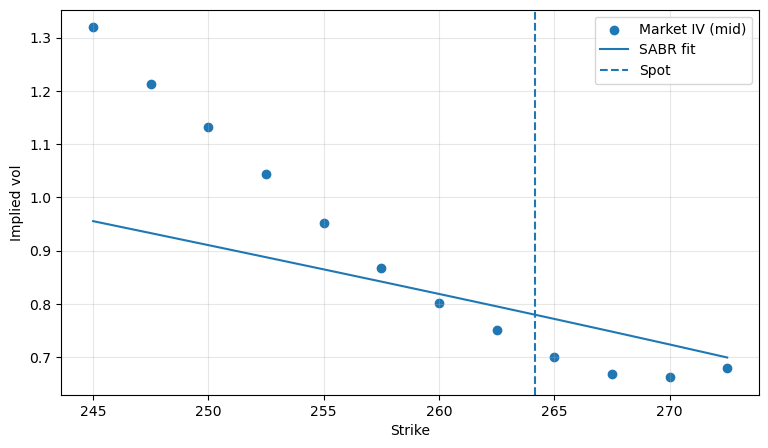

In [18]:
plt.figure(figsize=(9,5))

plt.scatter(smile_plot["strike"], smile_plot["iv_mid"], label="Market IV (mid)")
plt.plot(smile_plot["strike"], smile_plot["iv_sabr"], label="SABR fit")

plt.axvline(spot, linestyle="--", label="Spot")
# если хочешь именно форвард:
# plt.axvline(F, linestyle="--", label="Forward")

plt.xlabel("Strike")
plt.ylabel("Implied vol")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

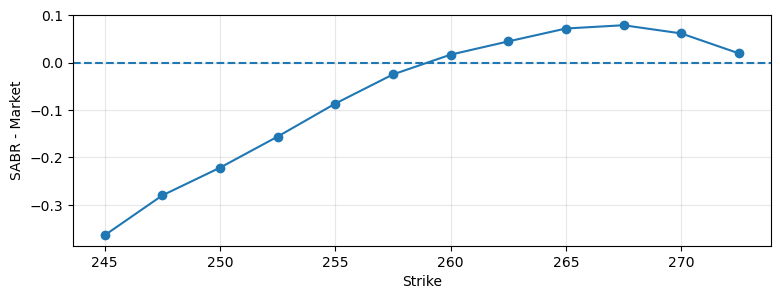

In [19]:
plt.figure(figsize=(9,3))
plt.plot(smile_plot["strike"], smile_plot["iv_sabr"] - smile_plot["iv_mid"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("SABR - Market")
plt.grid(True, alpha=0.3)
plt.show()